# Latar Belakang

Airbnb Bangkok memiliki banyak sekali listings (penginapan) beserta tipe - tipe yang tersedia. Dalam rangka untuk optimalisasi experience pelanggan serta preferensi penginapannya di Airbnb, Airbnb berniat untuk mengetahui seperti apa penginapan yang sering dipilih oleh pelanggan, as well as seperti apa karakteristik dari pelanggan - pelanggan tersebut.

## Problem Statement

Bagaimana karakteristik pelanggan Airbnb Bangkok dan tipe penginapan seperti apa yang paling sesuai dengan preferensi mereka?

# Data

## Data Understanding

Data yang akan digunakan adalah _summary_ dari listings (penginapan) yang tersedia pada Airbnb Bangkok. Data tersebut bisa ditemukan di [di sini](https://drive.google.com/drive/folders/1A_KBMRFTS5Mthpp46nulso679ML4ZwTF).

Data ini memuat beberapa kolom, yang di antara nya adalah kolom - kolom yang berhubungan dengan reviews, di mana kolom - kolom ini dapat menjawab problem statement yang ingin didalami oleh Airbnb Bangkok.

## Library Installation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
airbnb_df = pd.read_csv("Airbnb Listings Bangkok.csv")

## Data Cleansing

### Remove empty unnamed column

In [4]:
airbnb_df.drop(["Unnamed: 0"], axis = 1, inplace = True)

### Checking for the NULL column

In [5]:
airbnb_df.isna().sum()/airbnb_df.shape[0]*100

id                                 0.000000
name                               0.050460
host_id                            0.000000
host_name                          0.006308
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       36.520752
reviews_per_month                 36.520752
calculated_host_listings_count     0.000000
availability_365                   0.000000
number_of_reviews_ltm              0.000000
dtype: float64

Basically, data Airbnb listings di Bangkok ini relatively sudah bersih dari NULL. karena:
- hanya terdapat 0.05% NULL pada listing's name
- hanya terdapat 0.006% NULL pada host's name

dan:
- 36% NULL pada last_review dan reviews_per_month yg kemungkinan besar adalah listing yang memang belum menerima review

#### Handling NULL in listing's name and host's name

In [6]:
airbnb_df[airbnb_df["name"].isna()]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
439,4549768,NaN,18852579,Titawan,Phra Khanong,13.69406,100.59619,Private room,1080,5,0,NaN,NaN,1,365,0
544,4720818,NaN,24386225,Cherry,Din Daeng,13.77562,100.57346,Private room,1200,1,0,NaN,NaN,1,365,0
572,4245018,NaN,22030043,Parichart,Bang Phlat,13.78376,100.49821,Private room,1200,1,0,NaN,NaN,1,365,0
669,6148415,NaN,31895202,Chira,Bang Na,13.68276,100.60894,Entire home/apt,2424,2,0,NaN,NaN,1,365,0
1030,8055144,NaN,42521288,Nantida,Vadhana,13.74126,100.55761,Private room,5000,3,0,NaN,NaN,1,365,0
1282,10000742,NaN,51374914,Diamond Bangkok,Ratchathewi,13.75328,100.52928,Private room,930,1,6,2017-05-13,0.07,1,365,0
1594,10710165,NaN,55347997,Khaneungnit,Vadhana,13.71757,100.60464,Private room,1000,1,0,NaN,NaN,1,365,0
2075,13142743,NaN,73275200,Pakaphol,Khlong Toei,13.72566,100.56416,Private room,850,1,2,2017-12-11,0.03,3,220,0


In [7]:
airbnb_df["name"].fillna(airbnb_df["host_name"] + "'s property", inplace = True)
airbnb_df["host_name"].fillna(airbnb_df["name"] + "'s owner", inplace = True)

Rather than menghilangkan row data dari listing's name dan host's name yang NULL, mengisi listing's name dengan format "Host's name property" untuk listing's name dan "Listing's name's owner" untuk host's name yang NULL lebih baik, karena pengisian data pada listing's name dan host's name tidak begitu memengaruhi EDA

#### Handling NULL in last review and reviews_per_month

<Axes: >

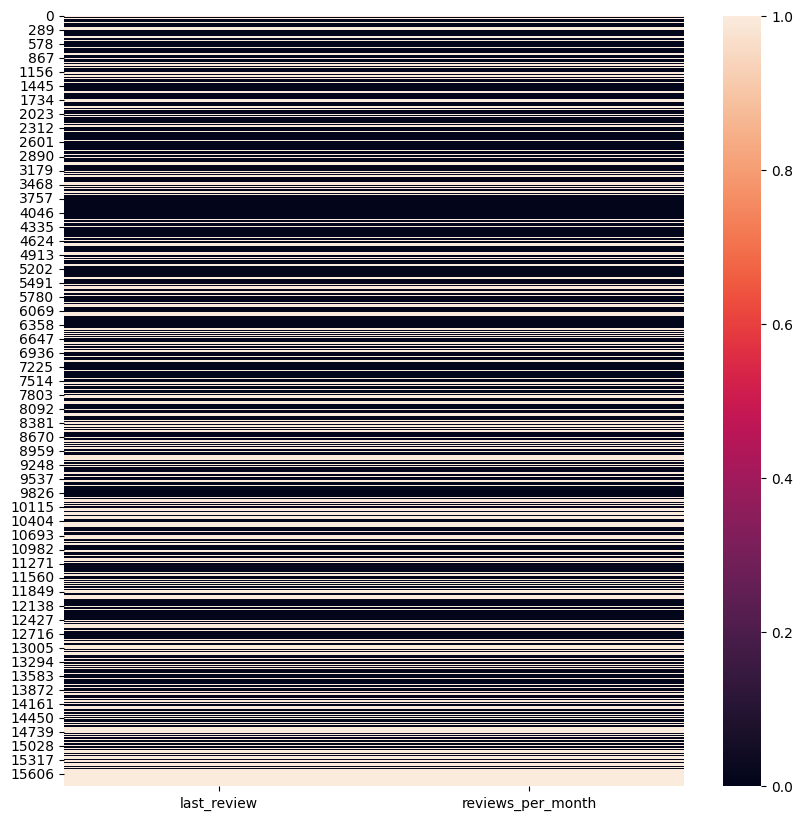

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(airbnb_df[["last_review", "reviews_per_month"]].isna())

Visualisasi di atas menunjukan hasil yang identical antara row data dari kolom last_review dan reviews_per_month yg memiliki NULL data. Hal ini menguatkan asumsi sebelumnya di mana last_review akan kosong apabila listing's belum memiliki review apapun, yang mengakibatkan reviews_per_month nya juga kosong

In [9]:
airbnb_df["reviews_per_month"].fillna(0, inplace = True)
airbnb_df["last_review"] = pd.to_datetime(airbnb_df["last_review"])

In [10]:
min_date = airbnb_df["last_review"].min()
max_date = airbnb_df["last_review"].max()

print(f"""
Last review paling lama terakhir diberikan pada tanggal: {min_date}, dan
Last review paling lama terakhir diberikan pada tanggal: {max_date}
""")


Last review paling lama terakhir diberikan pada tanggal: 2012-12-15 00:00:00, dan
Last review paling lama terakhir diberikan pada tanggal: 2022-12-28 00:00:00



### Remove List with Zero Price

In [11]:
airbnb_df.drop(airbnb_df[airbnb_df["price"] == 0].index, inplace = True)

Drop row data untuk listing yang memiliki harga 0 pada penginapannya lebih masuk akal dilakukan karena penginapan yang tidak memiliki harga tidak mungkin ada

# Data Analysis

## Final Data Prep

In [12]:
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15853 entries, 0 to 15853
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              15853 non-null  int64         
 1   name                            15853 non-null  object        
 2   host_id                         15853 non-null  int64         
 3   host_name                       15853 non-null  object        
 4   neighbourhood                   15853 non-null  object        
 5   latitude                        15853 non-null  float64       
 6   longitude                       15853 non-null  float64       
 7   room_type                       15853 non-null  object        
 8   price                           15853 non-null  int64         
 9   minimum_nights                  15853 non-null  int64         
 10  number_of_reviews               15853 non-null  int64         
 11  last_re

In [13]:
airbnb_df.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,0.00,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaT,0.00,1,365,0
3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.78823,100.57256,Private room,1286,7,2,2022-04-01,0.03,1,323,1
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.76872,100.63338,Private room,1905,1,0,NaT,0.00,3,365,0


### Segmenting Stay from Minimum Nights

In [15]:
airbnb_df.loc[(airbnb_df["minimum_nights"] >= 1) & (airbnb_df["minimum_nights"] <= 3), "minimum_night_grouped"] = "Short stays"
airbnb_df.loc[(airbnb_df["minimum_nights"] >= 4) & (airbnb_df["minimum_nights"] <= 10), "minimum_night_grouped"] = "Mid stays"
airbnb_df.loc[(airbnb_df["minimum_nights"] >= 11) & (airbnb_df["minimum_nights"] <= 30), "minimum_night_grouped"] = "Long stays"
airbnb_df.loc[(airbnb_df["minimum_nights"] > 30), "minimum_night_grouped"] = "Longer stays"

### Segmenting Pricing by Price

In [16]:
airbnb_df["price"].min()

np.int64(278)

In [17]:
airbnb_df["price"].max()

np.int64(1100000)

In [18]:
airbnb_df.loc[(airbnb_df["price"] >= 250) & (airbnb_df["price"] <= 1200), "price_grouped"] = "Budget"
airbnb_df.loc[(airbnb_df["price"] >= 1201) & (airbnb_df["price"] <= 3500), "price_grouped"] = "Standard"
airbnb_df.loc[(airbnb_df["price"] >= 3501) & (airbnb_df["price"] <= 10000), "price_grouped"] = "Premium"
airbnb_df.loc[(airbnb_df["price"] > 10001), "price_grouped"] = "Luxury"

## Verdict from EDA

*Short Stays dengan Pricing Standard di daerah Khlong Toei, Vadhana, dan Ratchathewi menjadi preferensi pilihan para pelanggan Airbnb.*

Hal ini terjadi karena:
- Asumsikan Total Reviews in the last 12 months adalah frekuensi jumlah pelanggan (demand) yang menginap, maka daerah Khlong Toei, Vadhana, dan Ratchathewi menjadi 3 daerah destinasi yang paling banyak dipilih dalam 12 bulan terakhir dengan total reviews 4000+
- Short Stays mengungguli segmentasi lama inap lain
- Serta pricing yang tidak terlalu murah, yet tidak terlalu mahal juga menjadi pilihan pelanggan, karena range harga tersebut dianggap sebagai _sweet spot_ yang dapat memenuhi kebutuhan mereka dalam menginap tapi tidak menurunkan standar pada kualitas penginapannya

## Breakdown Analysis

### Analysis by Neighborhood

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/2202768211.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='listing_cnt', y='neighbourhood', data=plot_data, palette='viridis')


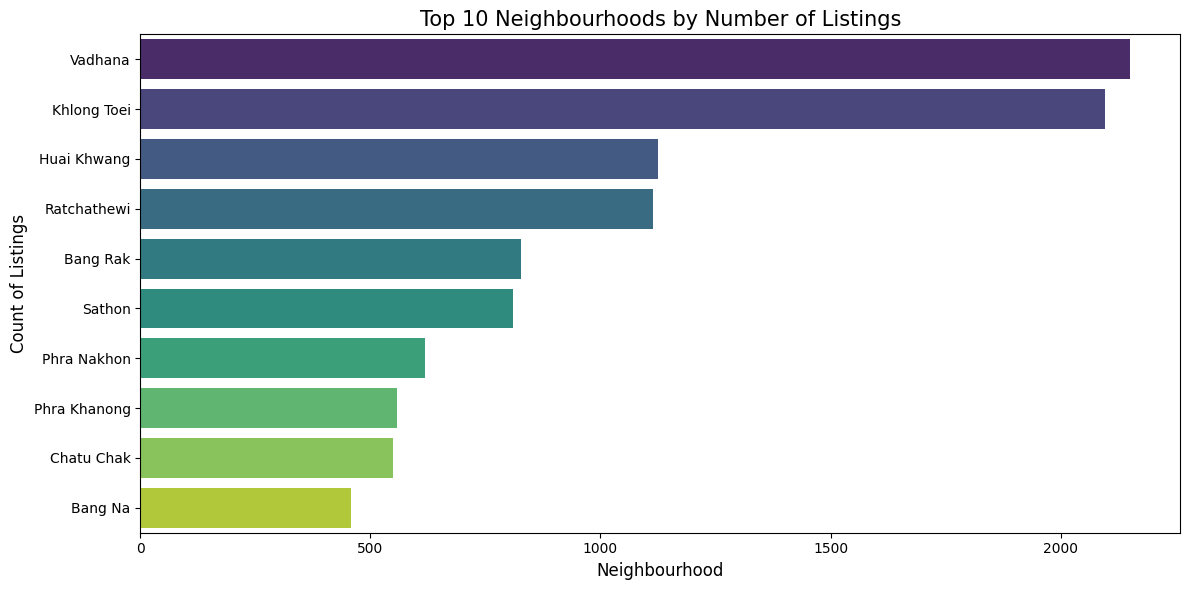

In [53]:
count_list_by_neighborhood = airbnb_df.groupby("neighbourhood")["id"].count().sort_values(ascending = False)
# count_list_by_neighborhood.head(10)

# preparing for visualization
plot_data = count_list_by_neighborhood.reset_index().head(10)
plot_data.columns = ["neighbourhood", "listing_cnt"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='listing_cnt', y='neighbourhood', data=plot_data, palette='viridis')
plt.title('Top 10 Neighbourhoods by Number of Listings', fontsize=15)
plt.xlabel('Neighbourhood', fontsize=12)
plt.ylabel('Count of Listings', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/1618693963.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='number_of_reviews_ltm', y='neighbourhood', data=plot_data, palette='viridis')


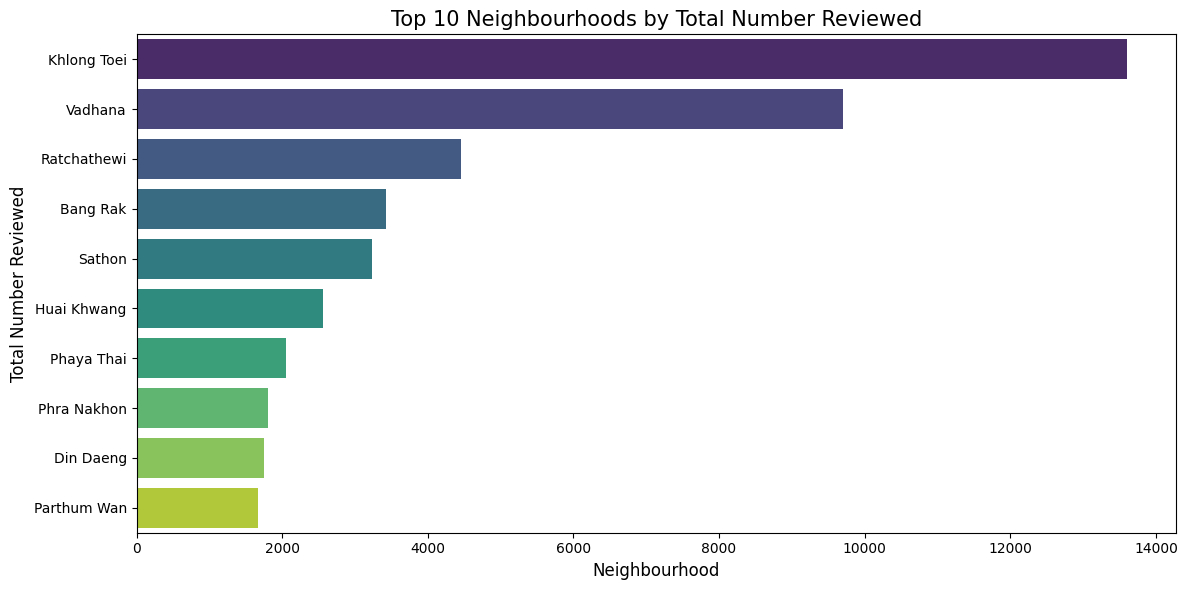

In [56]:
total_review_by_neighborhood = airbnb_df.groupby("neighbourhood")["number_of_reviews_ltm"].sum().sort_values(ascending = False)

# preparing for visualization
plot_data = total_review_by_neighborhood.reset_index().head(10)
plot_data.columns = ["neighbourhood", "number_of_reviews_ltm"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='number_of_reviews_ltm', y='neighbourhood', data=plot_data, palette='viridis')
plt.title('Top 10 Neighbourhoods by Total Number Reviewed', fontsize=15)
plt.xlabel('Neighbourhood', fontsize=12)
plt.ylabel('Total Number Reviewed', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/1768261877.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_reviews_per_list', y='neighbourhood', data=plot_data, palette='viridis')


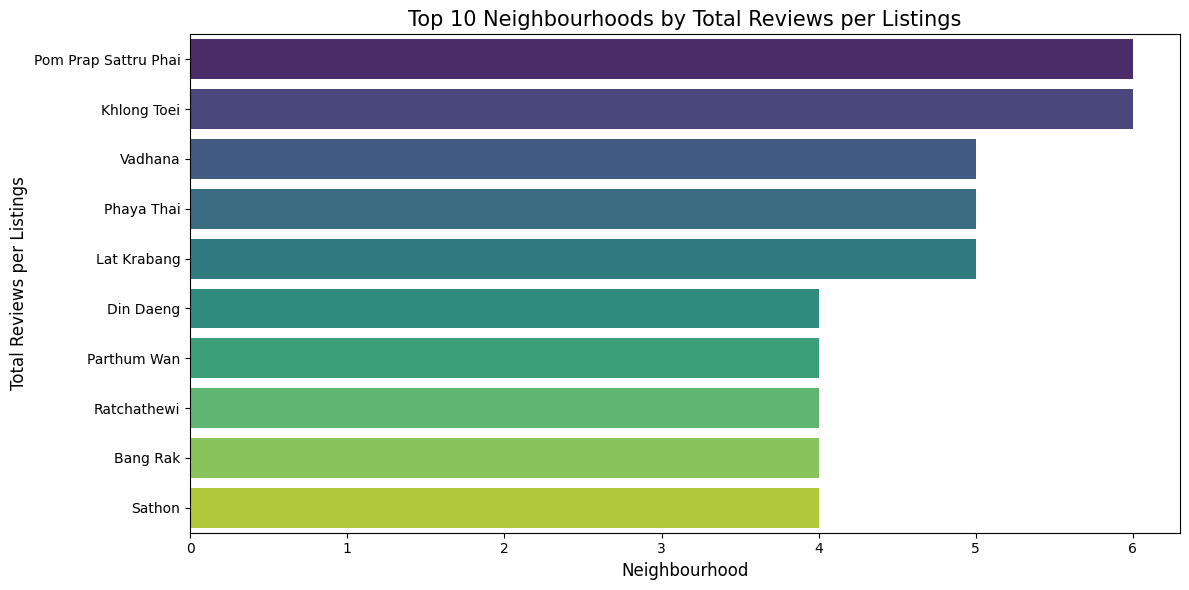

In [48]:
agg_df_reviews_per_list = airbnb_df.groupby("neighbourhood").agg(
    total_reviews=("number_of_reviews_ltm", "sum"),
    count_id=("id", "count")
)

reviews_per_list_by_neighborhood = round(agg_df_reviews_per_list["total_reviews"] / agg_df_reviews_per_list["count_id"],0).sort_values(ascending= False)

# preparing for visualization
plot_data = reviews_per_list_by_neighborhood.reset_index().head(10)
plot_data.columns = ["neighbourhood", "total_reviews_per_list"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='total_reviews_per_list', y='neighbourhood', data=plot_data, palette='viridis')
plt.title('Top 10 Neighbourhoods by Total Reviews per Listings', fontsize=15)
plt.xlabel('Neighbourhood', fontsize=12)
plt.ylabel('Total Reviews per Listings', fontsize=12)
plt.tight_layout()
plt.show()

In [51]:
agg_df_price_per_list = airbnb_df.groupby("neighbourhood").agg(
    total_price=("price", "sum"),
    count_id=("id", "count")
)

price_per_list_by_neighborhood = round(agg_df_price_per_list["total_price"] / agg_df_price_per_list["count_id"],0).sort_values(ascending= False)
price_per_list_by_neighborhood.sort_values(ascending= False).head(10)

# preparing for visualization
# plot_data = price_per_list_by_neighborhood.reset_index().head(10)
# plot_data.columns = ["neighbourhood", "total_price"]

# # visualization
# plt.figure(figsize=(12, 6))
# sns.barplot(x='total_price', y='neighbourhood', data=plot_data, palette='viridis')
# plt.title('Top 10 Neighbourhoods by Total Price per Listings', fontsize=15)
# plt.xlabel('Neighbourhood', fontsize=12)
# plt.ylabel('Total Price per Listings', fontsize=12)
# plt.tight_layout()
# plt.show()

neighbourhood
Bang Phlat         6257.0
Huai Khwang        5036.0
Khlong San         4772.0
Vadhana            4454.0
Parthum Wan        4356.0
Khlong Toei        4249.0
Lat Phrao          3539.0
Bang Khun thain    3405.0
Nong Chok          3280.0
Ratchathewi        3199.0
dtype: float64

In [ ]:
last_review_list_by_neighborhood = airbnb_df.groupby("neighbourhood")["last_review"].max().sort_values(ascending = False)
last_review_list_by_neighborhood.head(10)

neighbourhood
Yan na wa              2022-12-28
Din Daeng              2022-12-28
Sathon                 2022-12-28
Ratchathewi            2022-12-28
Pom Prap Sattru Phai   2022-12-28
Phra Nakhon            2022-12-28
Parthum Wan            2022-12-28
Vadhana                2022-12-28
Lak Si                 2022-12-28
Khlong Toei            2022-12-28
Name: last_review, dtype: datetime64[ns]

### Analysis by Room Type

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/57632322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='listing_cnt', y='room_type', data=plot_data, palette='viridis')


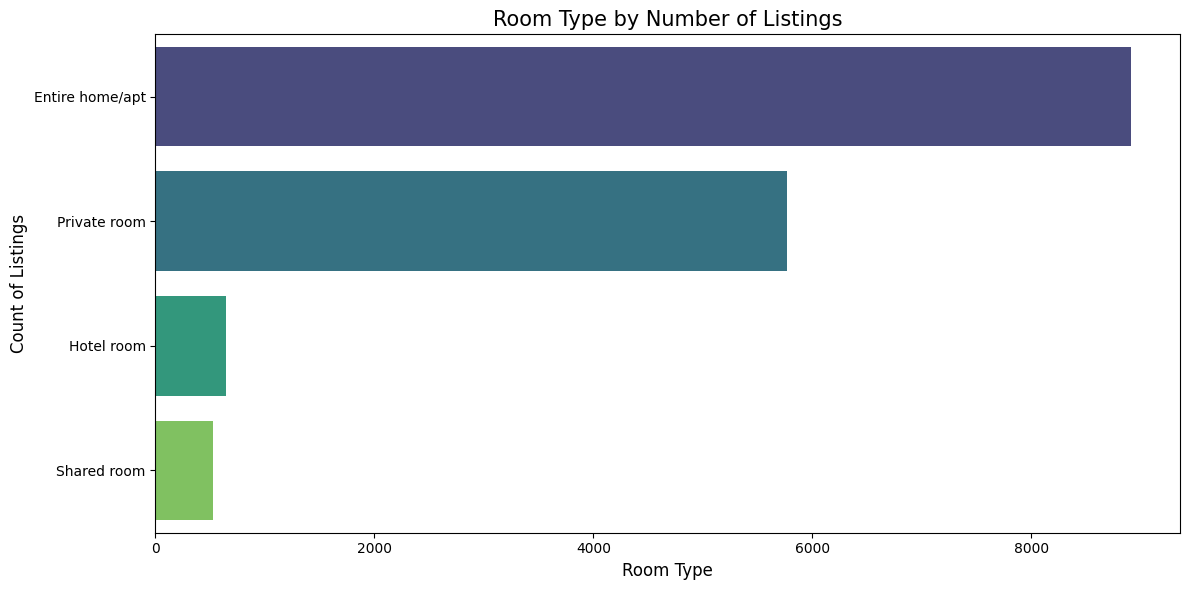

In [62]:
count_list_by_roomtype = airbnb_df.groupby("room_type")["id"].count().sort_values(ascending = False)
# count_list_by_neighborhood.head(10)

# preparing for visualization
plot_data = count_list_by_roomtype.reset_index().head(10)
plot_data.columns = ["room_type", "listing_cnt"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='listing_cnt', y='room_type', data=plot_data, palette='viridis')
plt.title('Room Type by Number of Listings', fontsize=15)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Count of Listings', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/3603173585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='number_of_reviews_ltm', y='room_type', data=plot_data, palette='viridis')


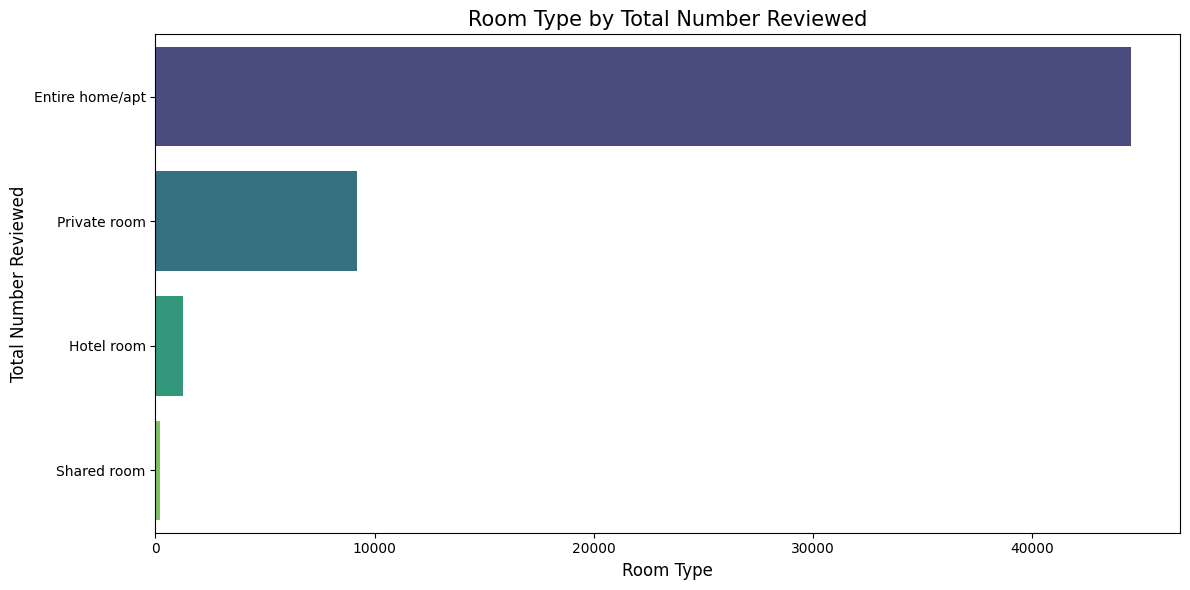

In [63]:
total_review_by_roomtype = airbnb_df.groupby("room_type")["number_of_reviews_ltm"].sum().sort_values(ascending = False)

# preparing for visualization
plot_data = total_review_by_roomtype.reset_index().head(10)
plot_data.columns = ["room_type", "number_of_reviews_ltm"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='number_of_reviews_ltm', y='room_type', data=plot_data, palette='viridis')
plt.title('Room Type by Total Number Reviewed', fontsize=15)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Total Number Reviewed', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/325203134.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_reviews_per_list', y='room_type', data=plot_data, palette='viridis')


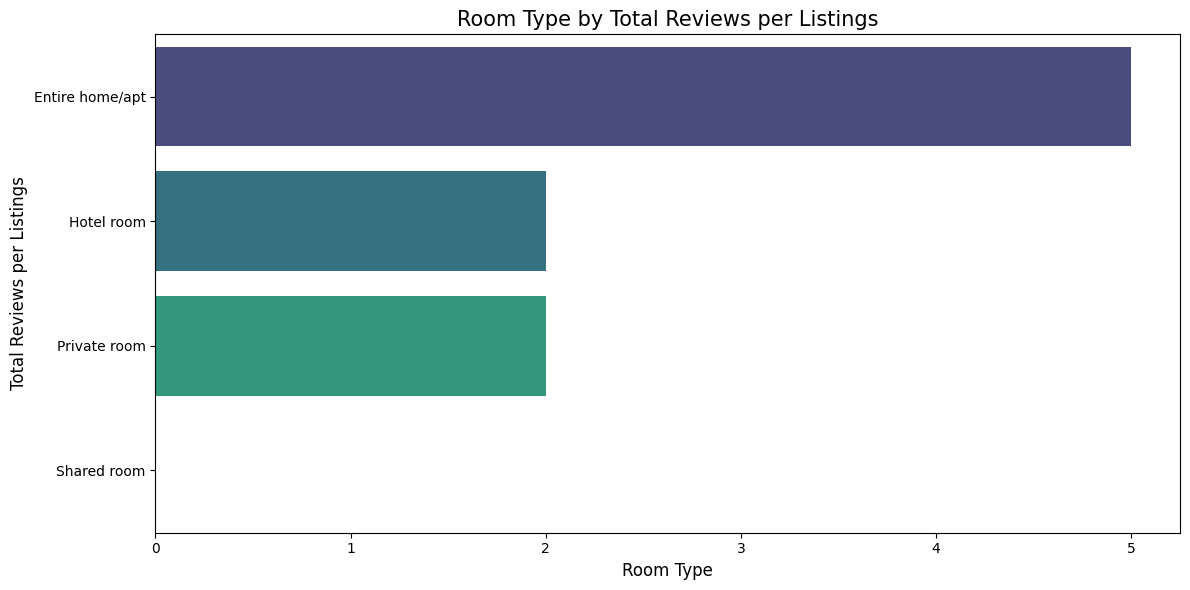

In [64]:
agg_df_reviews_per_list_room_type = airbnb_df.groupby("room_type").agg(
    total_reviews=("number_of_reviews_ltm", "sum"),
    count_id=("id", "count")
)

reviews_per_list_by_roomtype = round(agg_df_reviews_per_list_room_type["total_reviews"] / agg_df_reviews_per_list_room_type["count_id"],0).sort_values(ascending= False)

# preparing for visualization
plot_data = reviews_per_list_by_roomtype.reset_index().head(10)
plot_data.columns = ["room_type", "total_reviews_per_list"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='total_reviews_per_list', y='room_type', data=plot_data, palette='viridis')
plt.title('Room Type by Total Reviews per Listings', fontsize=15)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Total Reviews per Listings', fontsize=12)
plt.tight_layout()
plt.show()

In [61]:
agg_df_price_per_list_room_type = airbnb_df.groupby("room_type").agg(
    total_price=("price", "sum"),
    count_id=("id", "count")
)

price_per_list_by_roomtype = round(agg_df_price_per_list_room_type["total_price"] / agg_df_price_per_list_room_type["count_id"],0).sort_values(ascending= False)
price_per_list_by_roomtype.sort_values(ascending= False).head(10)

room_type
Entire home/apt    3465.0
Private room       3065.0
Hotel room         3033.0
Shared room         920.0
dtype: float64

### Analysis by Pricing Grouped

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/2700822858.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='listing_cnt', y='price_grouped', data=plot_data, palette='viridis')


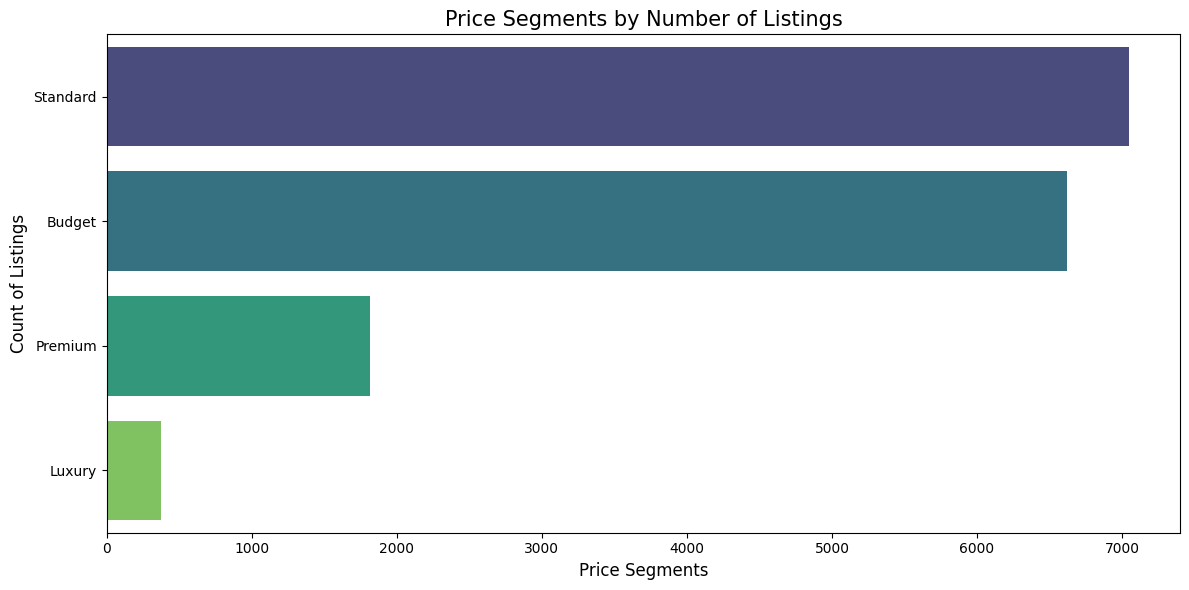

In [65]:
count_list_by_neighborhood = airbnb_df.groupby("price_grouped")["id"].count().sort_values(ascending = False)
# count_list_by_neighborhood.head(10)

# preparing for visualization
plot_data = count_list_by_neighborhood.reset_index().head(10)
plot_data.columns = ["price_grouped", "listing_cnt"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='listing_cnt', y='price_grouped', data=plot_data, palette='viridis')
plt.title('Price Segments by Number of Listings', fontsize=15)
plt.xlabel('Price Segments', fontsize=12)
plt.ylabel('Count of Listings', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/3514128464.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='number_of_reviews_ltm', y='price_grouped', data=plot_data, palette='viridis')


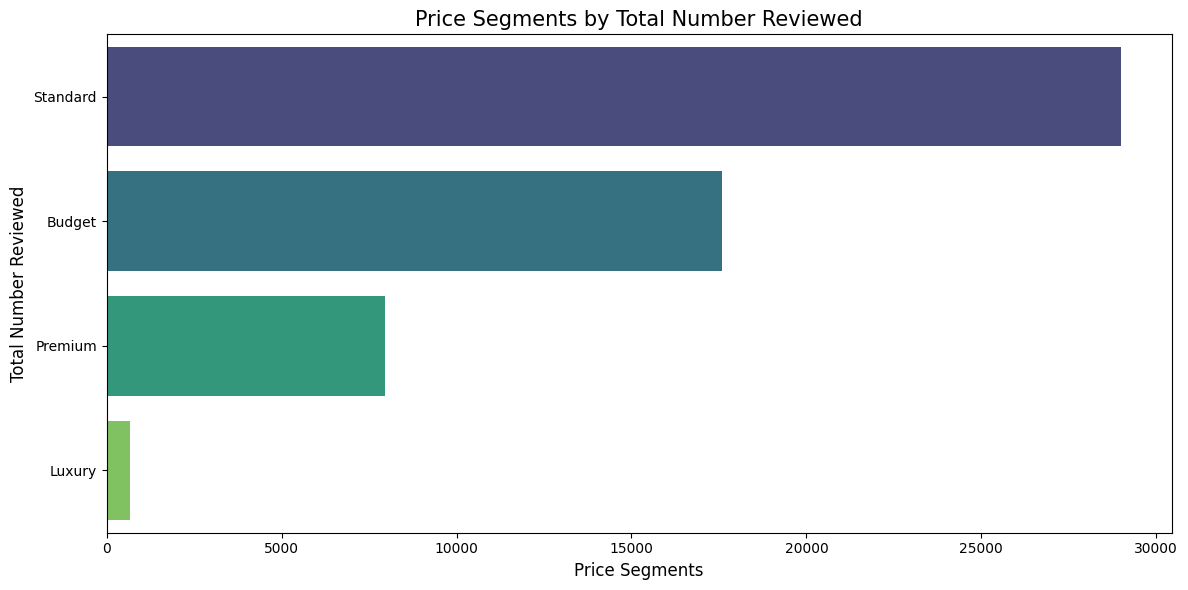

In [66]:
total_review_by_price = airbnb_df.groupby("price_grouped")["number_of_reviews_ltm"].sum().sort_values(ascending = False)

# preparing for visualization
plot_data = total_review_by_price.reset_index().head(10)
plot_data.columns = ["price_grouped", "number_of_reviews_ltm"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='number_of_reviews_ltm', y='price_grouped', data=plot_data, palette='viridis')
plt.title('Price Segments by Total Number Reviewed', fontsize=15)
plt.xlabel('Price Segments', fontsize=12)
plt.ylabel('Total Number Reviewed', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/4037703959.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_reviews_per_list', y='price_grouped', data=plot_data, palette='viridis')


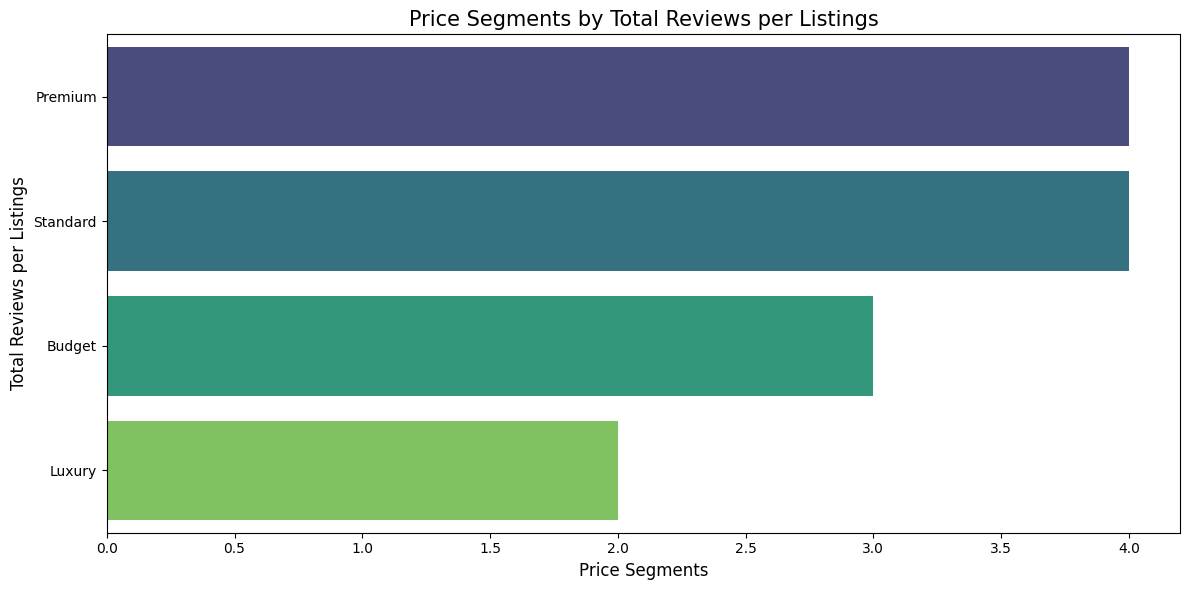

In [67]:
agg_df_reviews_per_list_price = airbnb_df.groupby("price_grouped").agg(
    total_reviews=("number_of_reviews_ltm", "sum"),
    count_id=("id", "count")
)

reviews_per_list_by_price = round(agg_df_reviews_per_list_price["total_reviews"] / agg_df_reviews_per_list_price["count_id"],0).sort_values(ascending= False)

# preparing for visualization
plot_data = reviews_per_list_by_price.reset_index().head(10)
plot_data.columns = ["price_grouped", "total_reviews_per_list"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='total_reviews_per_list', y='price_grouped', data=plot_data, palette='viridis')
plt.title('Price Segments by Total Reviews per Listings', fontsize=15)
plt.xlabel('Price Segments', fontsize=12)
plt.ylabel('Total Reviews per Listings', fontsize=12)
plt.tight_layout()
plt.show()

In [68]:
agg_df_price_per_list_price = airbnb_df.groupby("price_grouped").agg(
    total_price=("price", "sum"),
    count_id=("id", "count")
)

price_per_list_by_price = round(agg_df_price_per_list_price["total_price"] / agg_df_price_per_list_price["count_id"],0).sort_values(ascending= False)
price_per_list_by_price.sort_values(ascending= False).head(10)

price_grouped
Luxury      57488.0
Premium      5518.0
Standard     1994.0
Budget        817.0
dtype: float64

### Analysis by Minimum Nights Grouped

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/2225971889.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='listing_cnt', y='minimum_night_grouped', data=plot_data, palette='viridis')


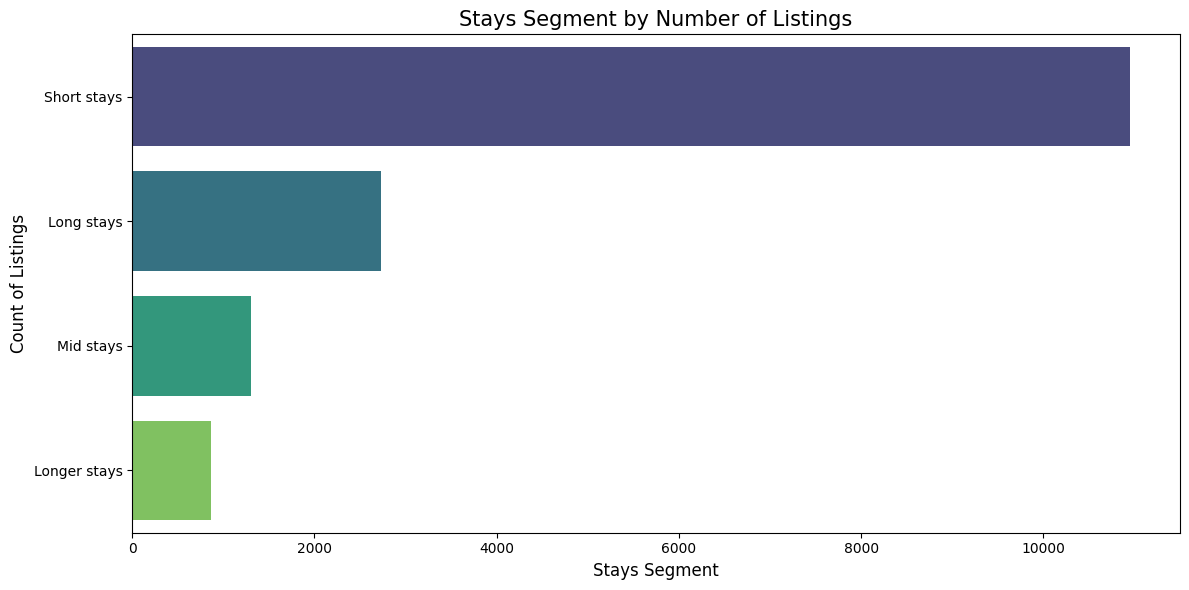

In [71]:
count_list_by_night = airbnb_df.groupby("minimum_night_grouped")["id"].count().sort_values(ascending = False)
# count_list_by_neighborhood.head(10)

# preparing for visualization
plot_data = count_list_by_night.reset_index().head(10)
plot_data.columns = ["minimum_night_grouped", "listing_cnt"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='listing_cnt', y='minimum_night_grouped', data=plot_data, palette='viridis')
plt.title('Stays Segment by Number of Listings', fontsize=15)
plt.xlabel('Stays Segment', fontsize=12)
plt.ylabel('Count of Listings', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/1194861026.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='number_of_reviews_ltm', y='minimum_night_grouped', data=plot_data, palette='viridis')


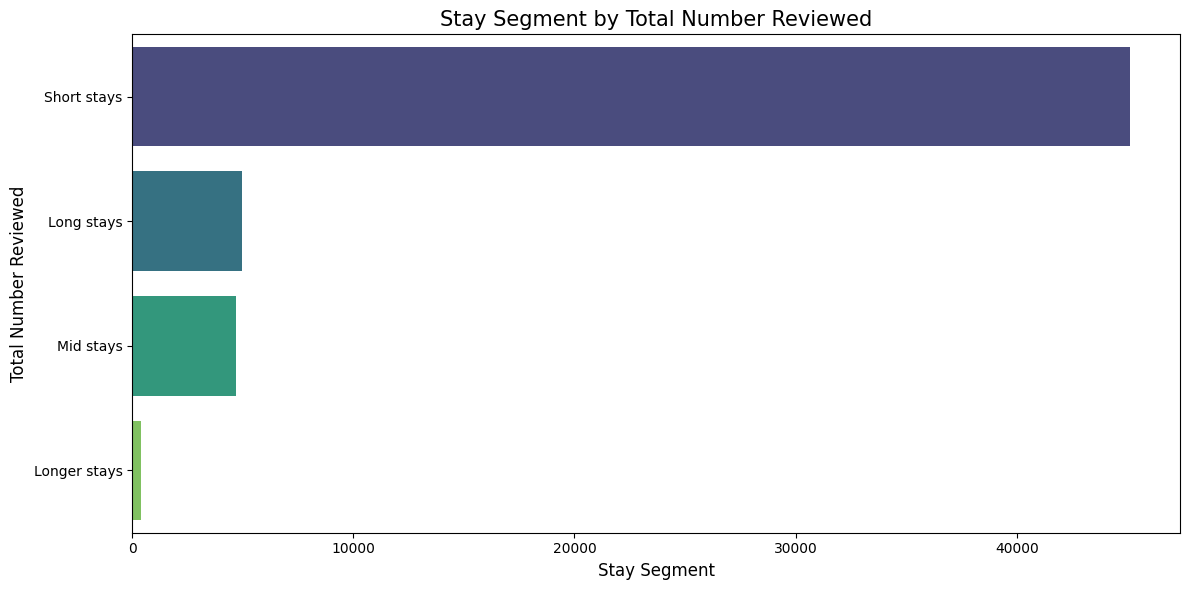

In [72]:
total_review_by_night = airbnb_df.groupby("minimum_night_grouped")["number_of_reviews_ltm"].sum().sort_values(ascending = False)

# preparing for visualization
plot_data = total_review_by_night.reset_index().head(10)
plot_data.columns = ["minimum_night_grouped", "number_of_reviews_ltm"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='number_of_reviews_ltm', y='minimum_night_grouped', data=plot_data, palette='viridis')
plt.title('Stay Segment by Total Number Reviewed', fontsize=15)
plt.xlabel('Stay Segment', fontsize=12)
plt.ylabel('Total Number Reviewed', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bn/n6kwrb_s5cq6sg96fz0_xlq00000gn/T/ipykernel_15471/506055634.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_reviews_per_list', y='minimum_night_grouped', data=plot_data, palette='viridis')


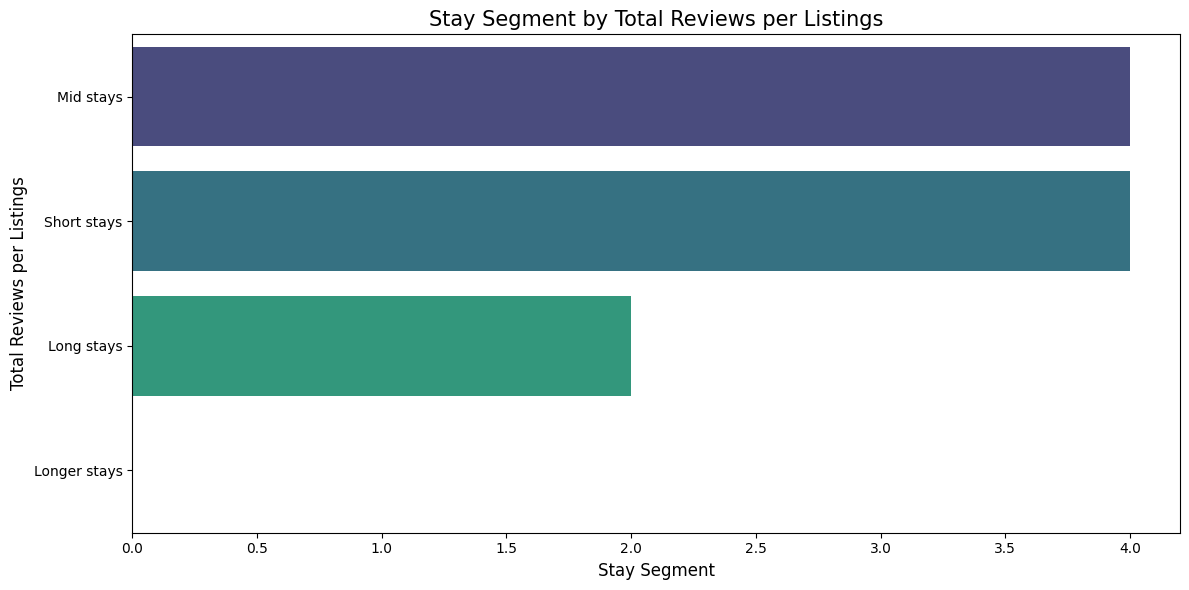

In [73]:
agg_df_reviews_per_list_night = airbnb_df.groupby("minimum_night_grouped").agg(
    total_reviews=("number_of_reviews_ltm", "sum"),
    count_id=("id", "count")
)

reviews_per_list_by_night = round(agg_df_reviews_per_list_night["total_reviews"] / agg_df_reviews_per_list_night["count_id"],0).sort_values(ascending= False)

# preparing for visualization
plot_data = reviews_per_list_by_night.reset_index().head(10)
plot_data.columns = ["minimum_night_grouped", "total_reviews_per_list"]

# visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='total_reviews_per_list', y='minimum_night_grouped', data=plot_data, palette='viridis')
plt.title('Stay Segment by Total Reviews per Listings', fontsize=15)
plt.xlabel('Stay Segment', fontsize=12)
plt.ylabel('Total Reviews per Listings', fontsize=12)
plt.tight_layout()
plt.show()

In [74]:
agg_df_price_per_list_night = airbnb_df.groupby("minimum_night_grouped").agg(
    total_price=("price", "sum"),
    count_id=("id", "count")
)

price_per_list_by_night = round(agg_df_price_per_list_night["total_price"] / agg_df_price_per_list_night["count_id"],0).sort_values(ascending= False)
price_per_list_by_night.sort_values(ascending= False).head(10)

minimum_night_grouped
Longer stays    5590.0
Long stays      3309.0
Short stays     3157.0
Mid stays       1958.0
dtype: float64

# Recommendation

Karena preferensi dari pelanggan based on karakteristik pilihan penginapan yang mereka sukai, most likely mereka adalah wisatawan atau business travelers.

Kita dapat memberikan beberapa hal untuk meningkatkan kualitas experience pelanggan dalam melakukan staycation via Airbnb dengan cara:
- Quick check in dan check out for efficiency. Karena tendensi pelanggan short stays cenderung ingin segala hal dilakukan secara _fast pace_
- Penyediaan guidebook visual untuk transportasi umum di daerah penginapan
- Fasilitas airport pickup
- Pantry bundling

In [76]:
airbnb_df.to_csv("cleaned_airbnb.csv")